# 🔦 MIRNet Inference — Load & Predict on New Images

This notebook loads the pre-trained **MIRNet** (Multi-Scale Residual Network) model
and enhances low-light images to verify that the trained model works correctly.

**Steps:**
1. Import dependencies
2. Define model architecture
3. Load saved checkpoint
4. Enhance test images & display results
5. Try your own images

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"  PyTorch: {torch.__version__}")

Device: cpu
  PyTorch: 2.11.0+cpu


---
## 1. Define MIRNet Architecture

We need to define the exact same model architecture that was used during training
so we can load the saved weights.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  Channel Attention (CA)
# ══════════════════════════════════════════════════════════════

class ChannelAttention(nn.Module):
    """
    Squeeze-and-Excitation channel attention.
    Global AvgPool -> FC -> ReLU -> FC -> Sigmoid -> scale.
    """
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.module = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(num_features, num_features // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(num_features // reduction, num_features, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.module(x).unsqueeze(-1).unsqueeze(-1)
        return x * weights


# ══════════════════════════════════════════════════════════════
#  Spatial Attention (SA)
# ══════════════════════════════════════════════════════════════

class SpatialAttention(nn.Module):
    """Spatial attention using conv layers."""
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.module = nn.Sequential(
            nn.Conv2d(num_features, num_features // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features // reduction, 1, kernel_size=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.module(x)
        return x * weights


# ══════════════════════════════════════════════════════════════
#  Dual Attention Unit (DAU)
# ══════════════════════════════════════════════════════════════

class DAU(nn.Module):
    """
    Dual Attention Unit: Channel Attention + Spatial Attention in parallel.
    Conv -> ReLU -> Conv -> Split -> (CA || SA) -> Sum -> Conv
    """
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1, bias=False),
        )
        self.ca = ChannelAttention(num_features, reduction)
        self.sa = SpatialAttention(num_features, reduction)
        self.conv_tail = nn.Conv2d(num_features * 2, num_features, kernel_size=1, bias=False)

    def forward(self, x):
        res = self.body(x)
        ca_out = self.ca(res)
        sa_out = self.sa(res)
        out = self.conv_tail(torch.cat([ca_out, sa_out], dim=1))
        return out + x


# ══════════════════════════════════════════════════════════════
#  Selective Kernel Feature Fusion (SKFF)
# ══════════════════════════════════════════════════════════════

class SKFF(nn.Module):
    """
    Selective Kernel Feature Fusion.
    Adaptively fuses multi-scale features using attention-based selection.
    """
    def __init__(self, num_features, num_paths=2, reduction=4):
        super().__init__()
        self.num_paths = num_paths
        d = max(num_features // reduction, 4)

        self.fc_squeeze = nn.Linear(num_features, d, bias=False)
        self.fcs = nn.ModuleList([
            nn.Linear(d, num_features, bias=False) for _ in range(num_paths)
        ])
        self.softmax = nn.Softmax(dim=1)

    def forward(self, feats):
        batch, channels, H, W = feats[0].shape
        fused = sum(feats)
        gap = F.adaptive_avg_pool2d(fused, 1).view(batch, channels)
        z = F.relu(self.fc_squeeze(gap))

        attention_vectors = [fc(z) for fc in self.fcs]
        attention_vectors = torch.stack(attention_vectors, dim=1)
        attention_vectors = self.softmax(attention_vectors)

        out = torch.zeros_like(feats[0])
        for i, feat in enumerate(feats):
            attn = attention_vectors[:, i, :].unsqueeze(-1).unsqueeze(-1)
            out = out + feat * attn

        return out


# ══════════════════════════════════════════════════════════════
#  Down-sampling & Up-sampling
# ══════════════════════════════════════════════════════════════

class DownSample(nn.Module):
    """Downsample 2x using strided convolution."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.down(x)


class UpSample(nn.Module):
    """Upsample 2x using sub-pixel convolution (PixelShuffle)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.Conv2d(in_channels, out_channels * 4, kernel_size=1, bias=False),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.up(x)


# ══════════════════════════════════════════════════════════════
#  Multi-Scale Residual Block (MRB)
# ══════════════════════════════════════════════════════════════

class MRB(nn.Module):
    """
    Multi-Scale Residual Block.
    Processes features at 2 scales with cross-scale connections.
    """
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.dau_s1 = DAU(num_features, reduction)
        self.dau_s2 = DAU(num_features, reduction)
        self.down_12 = DownSample(num_features, num_features)
        self.up_21   = UpSample(num_features, num_features)
        self.conv_s1 = nn.Conv2d(num_features * 2, num_features, kernel_size=1, bias=False)
        self.conv_s2 = nn.Conv2d(num_features * 2, num_features, kernel_size=1, bias=False)
        self.skff = SKFF(num_features, num_paths=2, reduction=reduction)

    def forward(self, x):
        x_s2 = self.down_12(x)
        out_s1 = self.dau_s1(x)
        out_s2 = self.dau_s2(x_s2)

        s2_to_s1 = self.up_21(out_s2)
        s2_to_s1 = F.interpolate(s2_to_s1, size=out_s1.shape[2:], mode='bilinear', align_corners=False)
        s1_fused = self.conv_s1(torch.cat([out_s1, s2_to_s1], dim=1))

        s1_to_s2 = self.down_12(out_s1)
        s1_to_s2 = F.interpolate(s1_to_s2, size=out_s2.shape[2:], mode='bilinear', align_corners=False)
        s2_fused = self.conv_s2(torch.cat([out_s2, s1_to_s2], dim=1))

        s2_up = F.interpolate(s2_fused, size=s1_fused.shape[2:], mode='bilinear', align_corners=False)
        out = self.skff([s1_fused, s2_up])

        return out + x


# ══════════════════════════════════════════════════════════════
#  Residual Recurrent Group (RRG)
# ══════════════════════════════════════════════════════════════

class RRG(nn.Module):
    """Stacks multiple MRBs with a long skip connection."""
    def __init__(self, num_features, num_mrb, reduction=4):
        super().__init__()
        modules = [MRB(num_features, reduction) for _ in range(num_mrb)]
        modules.append(nn.Conv2d(num_features, num_features, kernel_size=3, padding=1, bias=False))
        self.body = nn.Sequential(*modules)

    def forward(self, x):
        return self.body(x) + x


# ══════════════════════════════════════════════════════════════
#  Complete MIRNet Model
# ══════════════════════════════════════════════════════════════

class MIRNet(nn.Module):
    """
    MIRNet: Multi-Scale Residual Network for Image Restoration.

    Architecture:
      Input -> 3x3 Conv (shallow features)
            -> N x RRG (deep feature extraction)
            -> 3x3 Conv (reconstruction)
            -> + Input (global residual learning)
            -> Output
    """
    def __init__(self, in_channels=3, out_channels=3, n_features=64,
                 n_rrg=3, n_mrb=2, reduction=4):
        super().__init__()
        self.shallow_feat = nn.Conv2d(in_channels, n_features, kernel_size=3, padding=1, bias=False)
        self.rrgs = nn.Sequential(
            *[RRG(n_features, n_mrb, reduction) for _ in range(n_rrg)]
        )
        self.reconstruct = nn.Conv2d(n_features, out_channels, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        shallow = self.shallow_feat(x)
        deep = self.rrgs(shallow)
        out = self.reconstruct(deep)
        out = out + x
        return out.clamp(0, 1)


print("Model architecture defined successfully!")

Model architecture defined successfully!


---
## 2. Load Saved Checkpoint

Loading the best trained MIRNet model from `checkpoints_mirnet/mirnet_best.pth`.

In [ ]:
# ── Paths ──
# For Colab:
BASE_DIR = r"/content/drive/MyDrive/Final year project/final year project"
# BASE_DIR = r"."

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints_mirnet")
RESULTS_DIR = os.path.join(BASE_DIR, "test", "enhanced")
TEST_LOW_DIR = os.path.join(BASE_DIR, "test", "low")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Model Configuration (same as training) ──
IN_CHANNELS  = 3
OUT_CHANNELS = 3
N_FEATURES   = 64
N_RRG        = 3
N_MRB        = 2
REDUCTION    = 4

# ── Build Model ──
model = MIRNet(
    in_channels=IN_CHANNELS,
    out_channels=OUT_CHANNELS,
    n_features=N_FEATURES,
    n_rrg=N_RRG,
    n_mrb=N_MRB,
    reduction=REDUCTION
).to(device)

# ── Load Best Checkpoint ──
best_path = os.path.join(CHECKPOINT_DIR, 'mirnet_best.pth')

if os.path.exists(best_path):
    checkpoint = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    loaded_epoch = checkpoint.get('epoch', 'N/A')
    loaded_psnr = checkpoint.get('best_psnr', 'N/A')
    print(f"Loaded best checkpoint successfully!")
    print(f"  Epoch: {loaded_epoch}")
    print(f"  Best PSNR: {loaded_psnr:.2f} dB" if isinstance(loaded_psnr, (int, float)) else f"  Best PSNR: {loaded_psnr}")
else:
    print(f"ERROR: Checkpoint not found at {best_path}")
    print(f"Available checkpoints:")
    for f in os.listdir(CHECKPOINT_DIR):
        print(f"  - {f}")

model.eval()

# ── Model Summary ──
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Summary:")
print(f"  Architecture: MIRNet ({N_FEATURES}ch, {N_RRG} RRGs x {N_MRB} MRBs)")
print(f"  Parameters: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"  Model size: ~{total_params * 4 / 1e6:.1f} MB (FP32)")
print(f"  Device: {device}")
print(f"\nModel is ready for inference!")

Loaded best checkpoint successfully!
  Epoch: 130
  Best PSNR: 21.68 dB

Model Summary:
  Architecture: MIRNet (64ch, 3 RRGs x 2 MRBs)
  Parameters: 1,570,368 (1.6M)
  Model size: ~6.3 MB (FP32)
  Device: cpu

Model is ready for inference!


---
## 3. Enhancement Function

The `enhance_image` function handles padding (to make dimensions divisible by 8), inference, and un-padding.

In [ ]:
def enhance_image(img_tensor, model, device):
    """
    Enhance a single image using MIRNet.

    Args:
        img_tensor: [3, H, W] tensor in [0, 1]
        model: trained MIRNet
        device: cuda/cpu
    Returns:
        enhanced: [3, H, W] tensor in [0, 1]
    """
    model.eval()
    with torch.no_grad():
        _, H, W = img_tensor.shape
        # Pad to make dimensions divisible by 8
        pad_h = (8 - H % 8) % 8
        pad_w = (8 - W % 8) % 8

        x = img_tensor.unsqueeze(0).to(device)
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')

        enhanced = model(x)

        # Remove padding
        if pad_h > 0 or pad_w > 0:
            enhanced = enhanced[:, :, :H, :W]

        return enhanced.squeeze(0).clamp(0, 1).cpu()


def enhance_from_path(image_path, model, device, save_path=None):
    """
    Load, enhance, and display a single image from disk.

    Args:
        image_path: path to input low-light image
        model: trained MIRNet
        device: cuda/cpu
        save_path: optional path to save the enhanced image
    Returns:
        enhanced: [3, H, W] tensor
    """
    img = Image.open(image_path).convert('RGB')
    img_tensor = TF.to_tensor(img)

    print(f"  Input:  {os.path.basename(image_path)} ({img.size[0]}x{img.size[1]})")

    # Time the inference
    start = time.time()
    enhanced = enhance_image(img_tensor, model, device)
    elapsed = (time.time() - start) * 1000

    print(f"  Time:   {elapsed:.1f} ms")

    # Display side-by-side comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.imshow(img_tensor.permute(1, 2, 0).numpy())
    ax1.set_title('Input (Low-Light)', fontsize=14, fontweight='bold')
    ax1.axis('off')

    ax2.imshow(enhanced.permute(1, 2, 0).numpy())
    ax2.set_title('MIRNet Enhanced', fontsize=14, fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()

    if save_path:
        TF.to_pil_image(enhanced).save(save_path)
        print(f"  Saved:  {save_path}")

    plt.show()
    return enhanced


print("Enhancement functions defined!")

Enhancement functions defined!


---
## 4. Enhance Test Images

Run the model on test images from the `test/low/` folder and save results to `test/Enhanced/`.

Found 2 test image(s) in '/content/drive/MyDrive/narayana project/narayana project/test/low/'

Enhancing: test1.png
  Input:  test1.png (366x246)
  Time:   5768.4 ms
  Saved:  /content/drive/MyDrive/narayana project/narayana project/test/enhanced/enhanced_test1.png


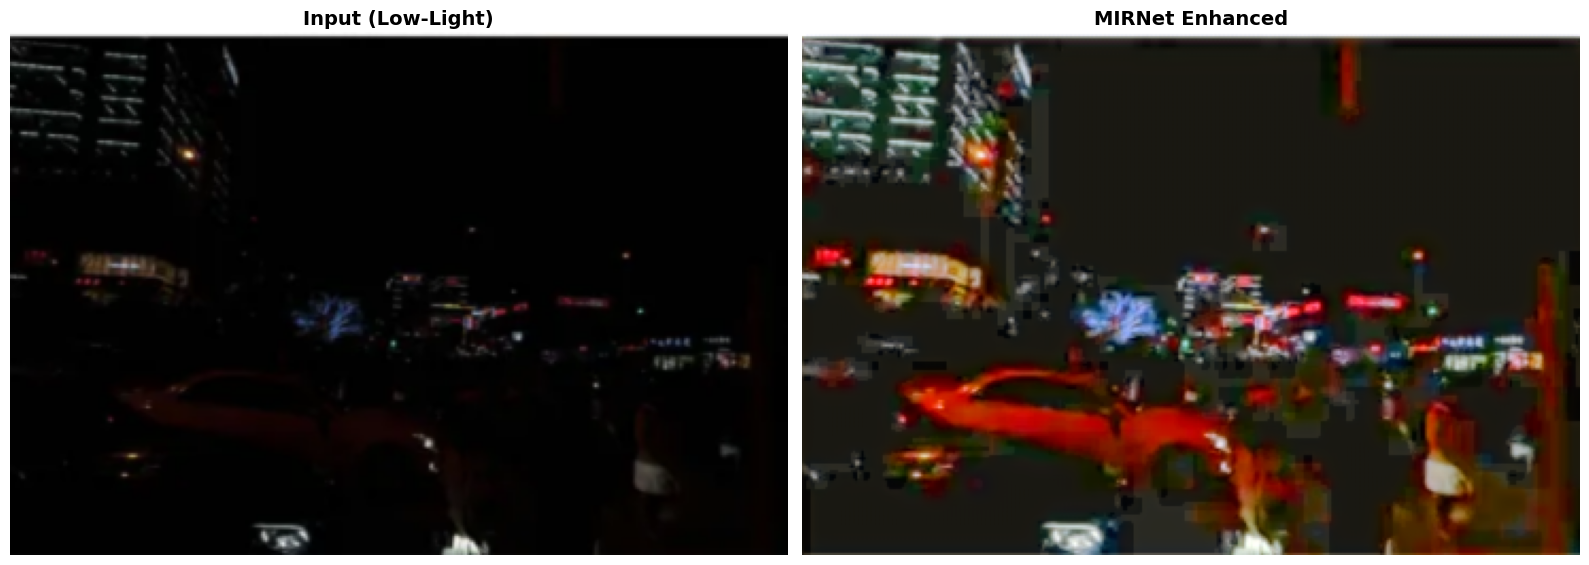


Enhancing: test2.png
  Input:  test2.png (324x219)
  Time:   3717.8 ms
  Saved:  /content/drive/MyDrive/narayana project/narayana project/test/enhanced/enhanced_test2.png


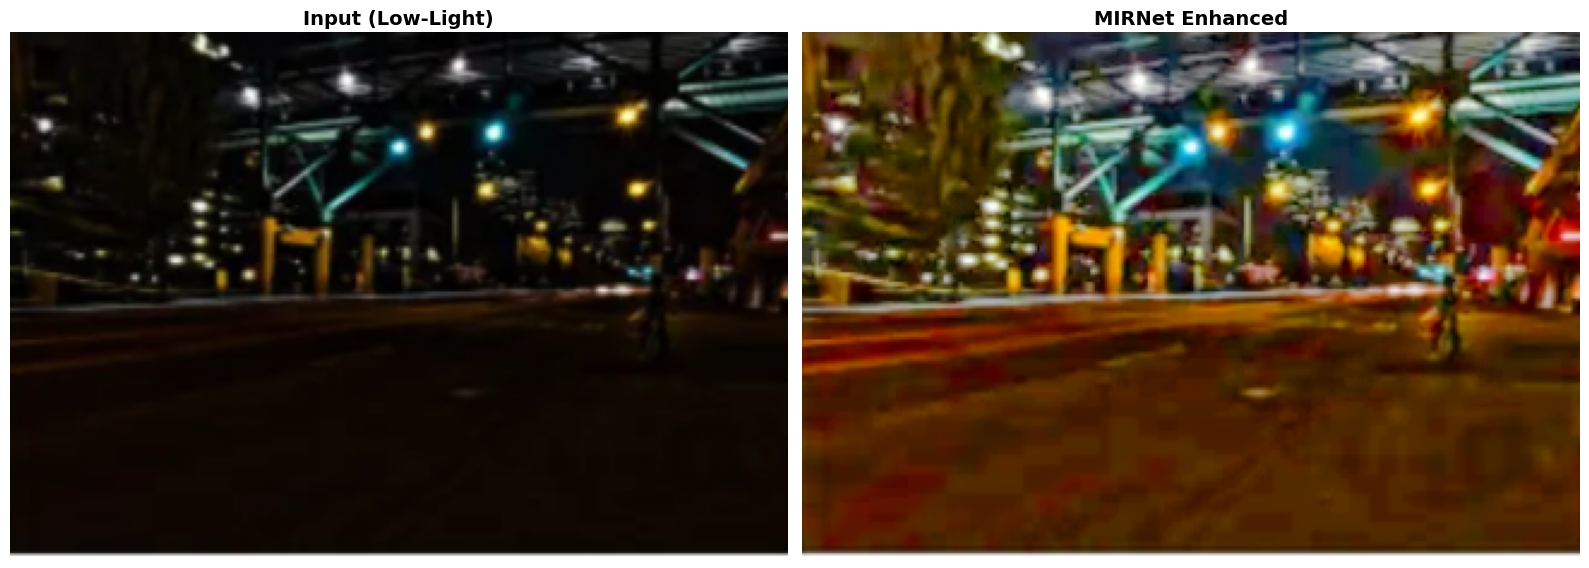


All enhanced images saved to '/content/drive/MyDrive/narayana project/narayana project/test/enhanced/'


In [ ]:
# ── Enhance all images in test/low/ ──
test_images = sorted([
    f for f in os.listdir(TEST_LOW_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

print(f"Found {len(test_images)} test image(s) in '{TEST_LOW_DIR}/'")
print("=" * 60)

for img_name in test_images:
    img_path = os.path.join(TEST_LOW_DIR, img_name)
    save_name = f"enhanced_{img_name}"
    save_path = os.path.join(RESULTS_DIR, save_name)

    print(f"\nEnhancing: {img_name}")
    enhanced = enhance_from_path(img_path, model, device, save_path=save_path)

print("\n" + "=" * 60)
print(f"All enhanced images saved to '{RESULTS_DIR}/'")

---
## 5. Detailed Comparison View

Side-by-side comparison of all test images with zoom-in details.

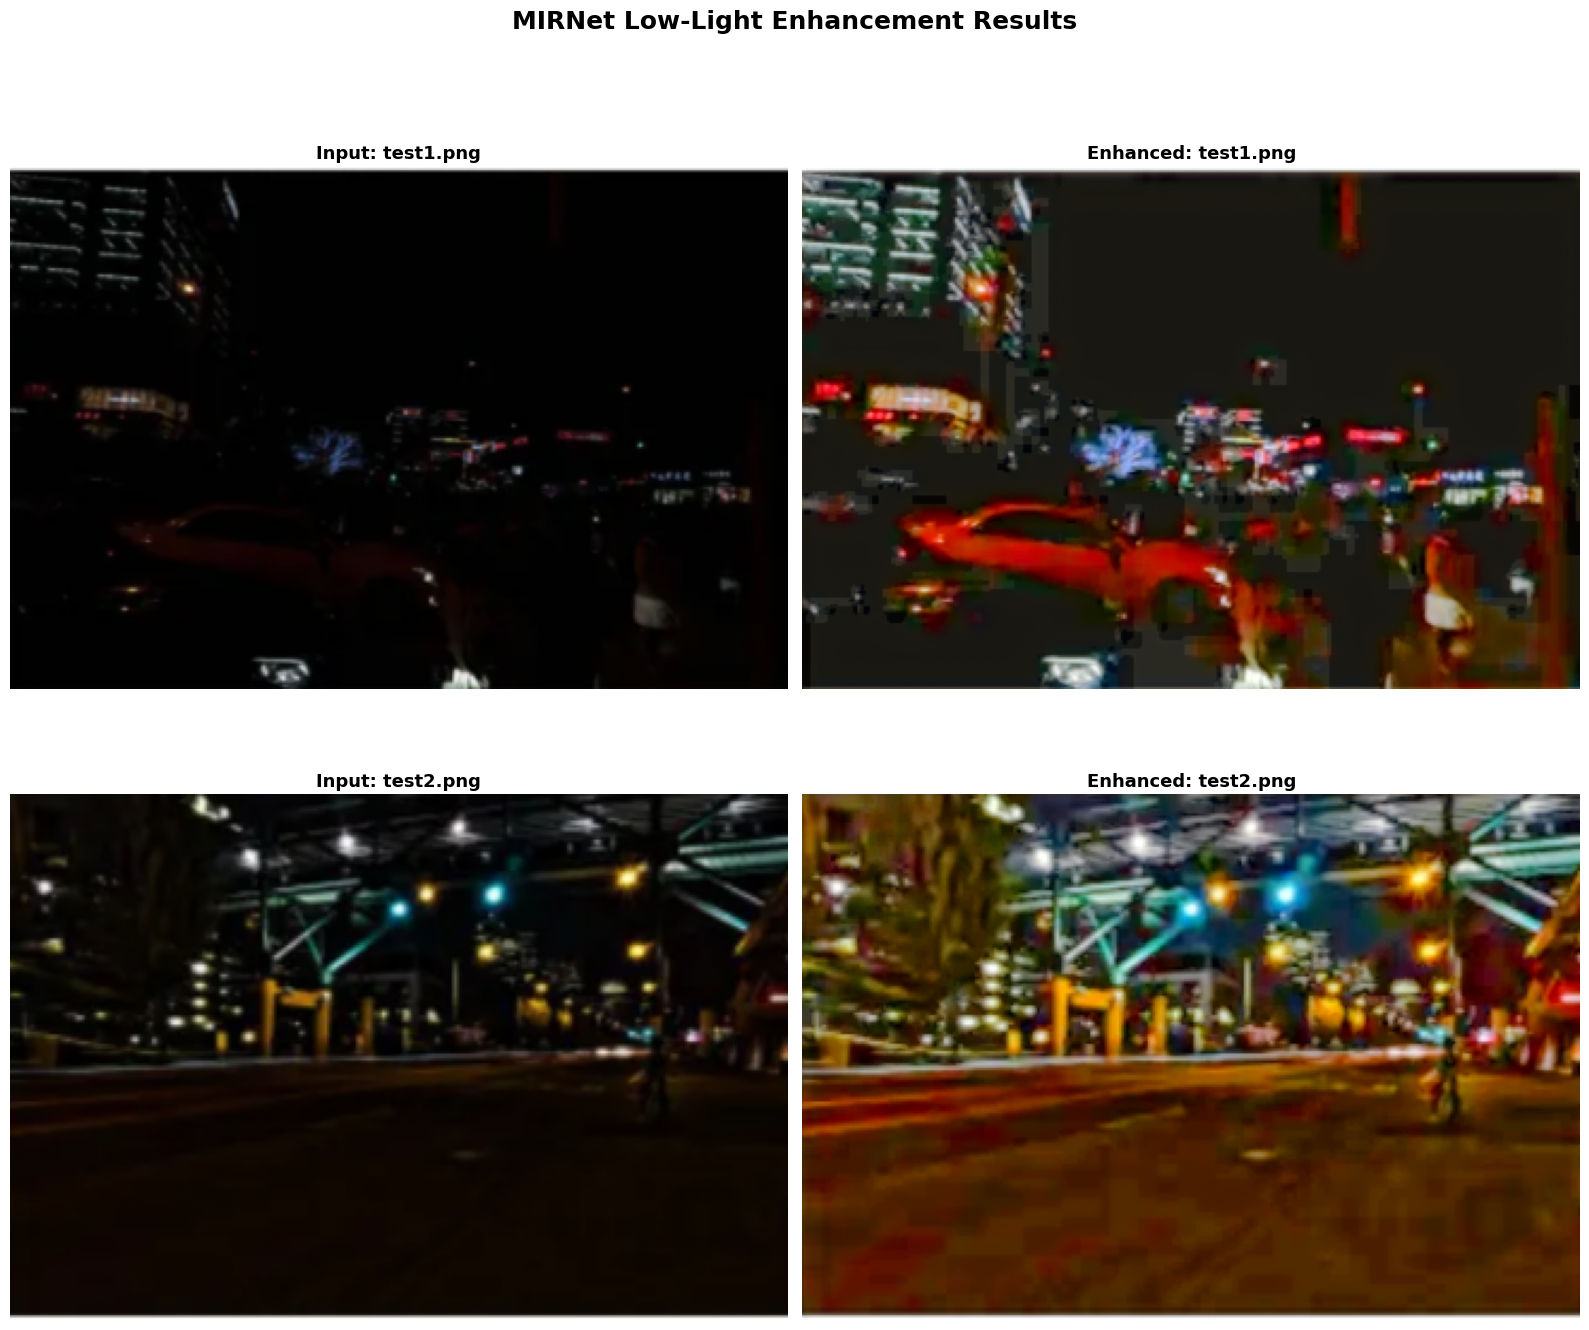

Displayed 2 comparison(s)


In [ ]:
# ── Comparison Gallery ──
test_images = sorted([
    f for f in os.listdir(TEST_LOW_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

n_images = len(test_images)
fig, axes = plt.subplots(n_images, 2, figsize=(16, 7 * n_images))

if n_images == 1:
    axes = axes.reshape(1, -1)

for idx, img_name in enumerate(test_images):
    # Load original
    img_path = os.path.join(TEST_LOW_DIR, img_name)
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img) / 255.0


    # Load enhanced
    enhanced_path = os.path.join(RESULTS_DIR, f"enhanced_{img_name}")
    if os.path.exists(enhanced_path):
        enh = Image.open(enhanced_path).convert('RGB')
        enh_np = np.array(enh) / 255.0
    else:
        # Re-enhance if saved file not found
        img_tensor = TF.to_tensor(img)
        enhanced = enhance_image(img_tensor, model, device)
        enh_np = enhanced.permute(1, 2, 0).numpy()

    # Display
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f'Input: {img_name}', fontsize=13, fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(enh_np)
    axes[idx, 1].set_title(f'Enhanced: {img_name}', fontsize=13, fontweight='bold')
    axes[idx, 1].axis('off')

plt.suptitle('MIRNet Low-Light Enhancement Results', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Displayed {n_images} comparison(s)")

---
## 6. Pixel Statistics & Quality Check

Verify that the model is actually enhancing images by checking pixel distributions.

In [ ]:
# ── Pixel Statistics Analysis ──
print("Pixel Statistics Analysis")
print("=" * 65)
print(f"{'Image':<20} {'Type':<10} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 65)

test_images = sorted([
    f for f in os.listdir(TEST_LOW_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

for img_name in test_images:
    # Load original
    img_path = os.path.join(TEST_LOW_DIR, img_name)
    img = np.array(Image.open(img_path).convert('RGB')) / 255.0

    # Load enhanced
    enhanced_path = os.path.join(RESULTS_DIR, f"enhanced_{img_name}")
    if os.path.exists(enhanced_path):
        enh = np.array(Image.open(enhanced_path).convert('RGB')) / 255.0
    else:
        img_tensor = TF.to_tensor(Image.open(img_path).convert('RGB'))
        enhanced = enhance_image(img_tensor, model, device)
        enh = enhanced.permute(1, 2, 0).numpy()

    print(f"{img_name:<20} {'Input':<10} {img.mean():>8.4f} {img.std():>8.4f} {img.min():>6.3f} {img.max():>6.3f}")
    print(f"{'':<20} {'Enhanced':<10} {enh.mean():>8.4f} {enh.std():>8.4f} {enh.min():>6.3f} {enh.max():>6.3f}")

    brightness_boost = (enh.mean() / img.mean() - 1) * 100
    print(f"{'':<20} {'Boost':<10} {brightness_boost:>+7.1f}%")
    print("-" * 65)

print("\nIf 'Boost' is positive, the model is successfully enhancing brightness!")

Pixel Statistics Analysis
Image                Type           Mean      Std    Min    Max
-----------------------------------------------------------------
test1.png            Input        0.0258   0.0961  0.000  0.996
                     Enhanced     0.1546   0.1688  0.000  1.000
                     Boost       +500.4%
-----------------------------------------------------------------
test2.png            Input        0.0666   0.1210  0.000  1.000
                     Enhanced     0.2254   0.2037  0.000  1.000
                     Boost       +238.3%
-----------------------------------------------------------------

If 'Boost' is positive, the model is successfully enhancing brightness!


---
## 7. Histogram Comparison

Compare pixel intensity histograms between input and enhanced images.

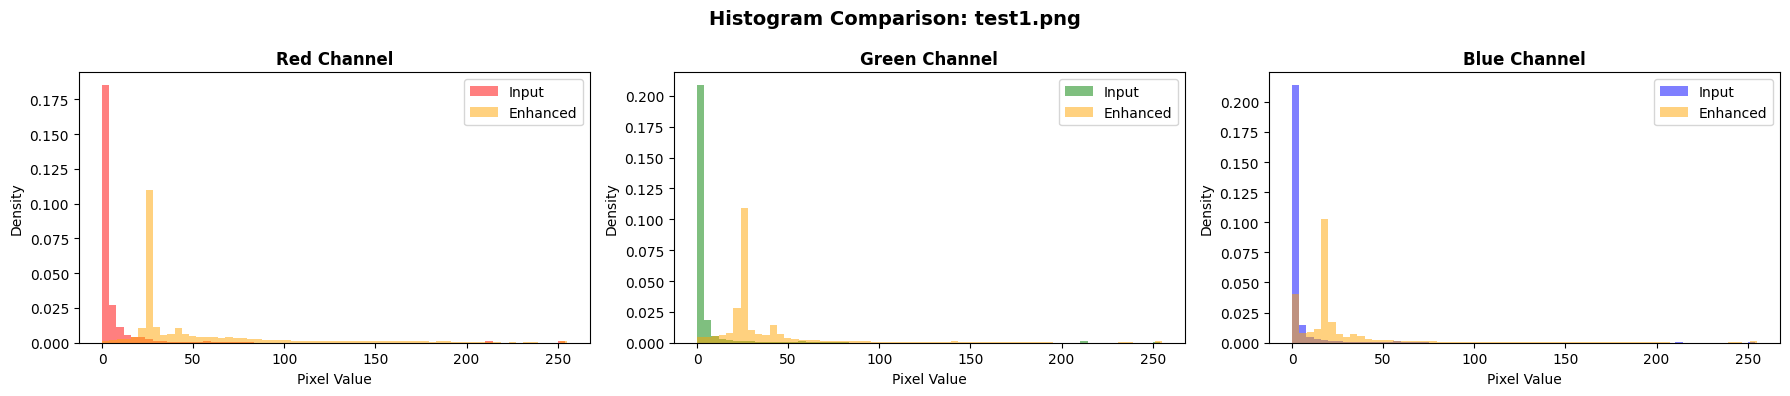

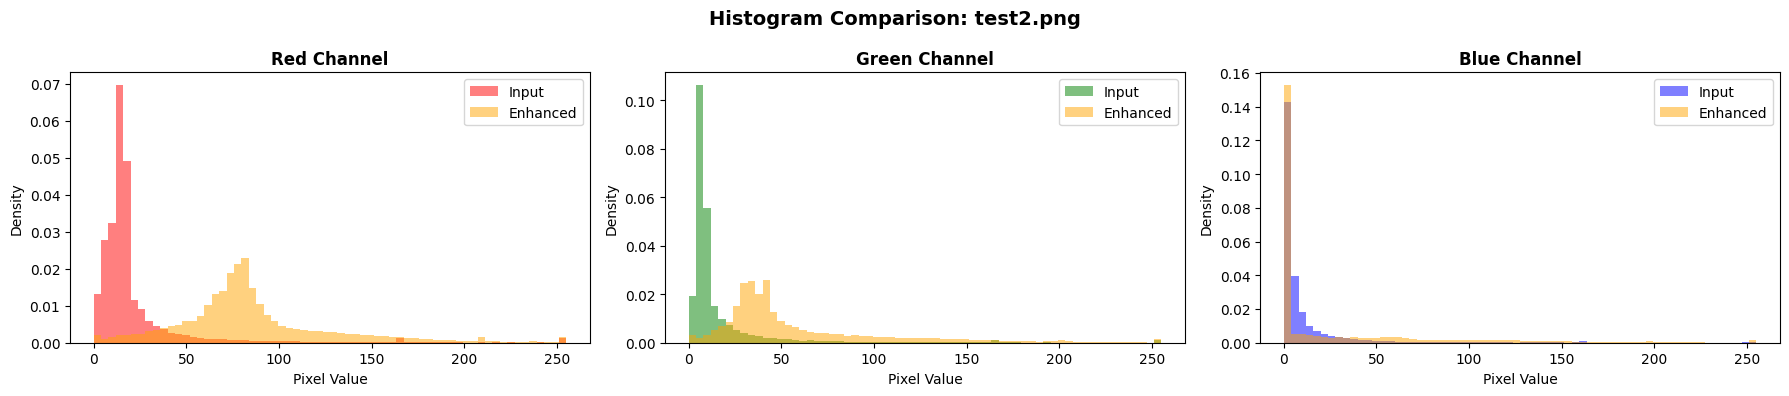

In [ ]:
# ── Histogram Comparison ──
test_images = sorted([
    f for f in os.listdir(TEST_LOW_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

for img_name in test_images:
    img_path = os.path.join(TEST_LOW_DIR, img_name)
    img = np.array(Image.open(img_path).convert('RGB'))

    enhanced_path = os.path.join(RESULTS_DIR, f"enhanced_{img_name}")
    if os.path.exists(enhanced_path):
        enh = np.array(Image.open(enhanced_path).convert('RGB'))
    else:
        img_tensor = TF.to_tensor(Image.open(img_path).convert('RGB'))
        enhanced = enhance_image(img_tensor, model, device)
        enh = (enhanced.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    colors = ['red', 'green', 'blue']
    channel_names = ['Red', 'Green', 'Blue']

    for c_idx, (color, name) in enumerate(zip(colors, channel_names)):
        axes[c_idx].hist(img[:,:,c_idx].ravel(), bins=64, alpha=0.5,
                        color=color, label='Input', density=True)
        axes[c_idx].hist(enh[:,:,c_idx].ravel(), bins=64, alpha=0.5,
                        color='orange', label='Enhanced', density=True)
        axes[c_idx].set_title(f'{name} Channel', fontsize=12, fontweight='bold')
        axes[c_idx].set_xlabel('Pixel Value')
        axes[c_idx].set_ylabel('Density')
        axes[c_idx].legend()

    plt.suptitle(f'Histogram Comparison: {img_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 8. Try Your Own Image

Place any low-light image in the `test/low/` folder, or provide a direct path below to enhance it.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  CHANGE THIS PATH to your own low-light image
# ══════════════════════════════════════════════════════════════

# Option 1: Use an image from the test/low/ folder
your_image_path = r"test/low/test1.png"

# Option 2: Use any image path on your system
# your_image_path = r"C:\path\to\your\dark_image.jpg"

# ── Enhance ──
if os.path.exists(your_image_path):
    print(f"Enhancing: {your_image_path}")
    save_path = os.path.join(RESULTS_DIR, f"enhanced_{os.path.basename(your_image_path)}")
    enhanced = enhance_from_path(your_image_path, model, device, save_path=save_path)
    print(f"\nDone! Enhanced image saved to: {save_path}")
else:
    print(f"Image not found: {your_image_path}")
    print("Please update the 'your_image_path' variable with a valid image path.")

Image not found: test/low/test1.png
Please update the 'your_image_path' variable with a valid image path.


---
## 9. Load Different Checkpoints (Optional)

You can also load other checkpoints (e.g., epoch-specific) to compare.

In [ ]:
# ── List all available checkpoints ──
print("Available checkpoints:")
print("-" * 50)
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    if f.endswith('.pth'):
        fpath = os.path.join(CHECKPOINT_DIR, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"  {f:<30s} ({size_mb:.1f} MB)")

# ── To load a different checkpoint, uncomment and modify: ──
# checkpoint_name = 'mirnet_epoch150.pth'
# ckpt_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)
# checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()
# print(f"\nLoaded: {checkpoint_name}")

Available checkpoints:
--------------------------------------------------
  mirnet_best.pth                (18.1 MB)
  mirnet_epoch100.pth            (18.1 MB)
  mirnet_epoch125.pth            (18.1 MB)
  mirnet_epoch150.pth            (18.1 MB)
  mirnet_epoch25.pth             (18.1 MB)
  mirnet_epoch50.pth             (18.1 MB)
  mirnet_epoch75.pth             (18.1 MB)
  mirnet_final.pth               (18.1 MB)


---
## 10. Batch Enhancement

Enhance multiple images at once and save all results.

In [ ]:
# ── Batch Enhancement ──
INPUT_DIR = r"/content/drive/MyDrive/narayana project/narayana project/test/low"     # Folder containing low-light images
OUTPUT_DIR = r"/content/drive/MyDrive/narayana project/narayana project/test/enhanced"  # Folder to save enhanced images

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get all image files
image_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

print(f"Batch Enhancement")
print(f"  Input:  {INPUT_DIR}/ ({len(image_files)} images)")
print(f"  Output: {OUTPUT_DIR}/")
print("=" * 50)

total_time = 0
for i, img_name in enumerate(image_files, 1):
    img_path = os.path.join(INPUT_DIR, img_name)
    save_path = os.path.join(OUTPUT_DIR, f"enhanced_{img_name}")

    img = Image.open(img_path).convert('RGB')
    img_tensor = TF.to_tensor(img)

    start = time.time()
    enhanced = enhance_image(img_tensor, model, device)
    elapsed = (time.time() - start) * 1000
    total_time += elapsed

    TF.to_pil_image(enhanced).save(save_path)
    print(f"  [{i}/{len(image_files)}] {img_name} -> enhanced_{img_name} ({elapsed:.1f} ms)")

print("=" * 50)
print(f"Done! {len(image_files)} images enhanced in {total_time:.1f} ms total")
print(f"Average: {total_time / len(image_files):.1f} ms per image")
print(f"Results saved to: {OUTPUT_DIR}/")

Batch Enhancement
  Input:  /content/drive/MyDrive/narayana project/narayana project/test/low/ (2 images)
  Output: /content/drive/MyDrive/narayana project/narayana project/test/enhanced/
  [1/2] test1.png -> enhanced_test1.png (4841.5 ms)
  [2/2] test2.png -> enhanced_test2.png (3382.9 ms)
Done! 2 images enhanced in 8224.4 ms total
Average: 4112.2 ms per image
Results saved to: /content/drive/MyDrive/narayana project/narayana project/test/enhanced/
